In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
print("Library imported")

Library imported


In [6]:
df = pd.read_csv('../data/nigeria.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [7]:
df['Country'] ='Nigeria'
df['Date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'],format='%Y%j')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [8]:
#check if there is any null value
print((df==-999).sum().sum())

0


In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.248907,3.477046


In [10]:
#check outliers
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df_outliers = df[weather_cols].copy()
z_score = np.abs(stats.zscore(df_outliers))
outliers = (z_score > 3)
outliers_row = outliers.any(axis=1).sum()
print(outliers_row)

225


In [11]:
#create a cleared data
import os 
makedir = os.makedirs('data',exist_ok=True)
df.to_csv('../data/nigeria_clean.csv')
print('Clean file created')
df.head()

Clean file created


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Year,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,2015,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,2015,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,2015,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,2015,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,2015,1


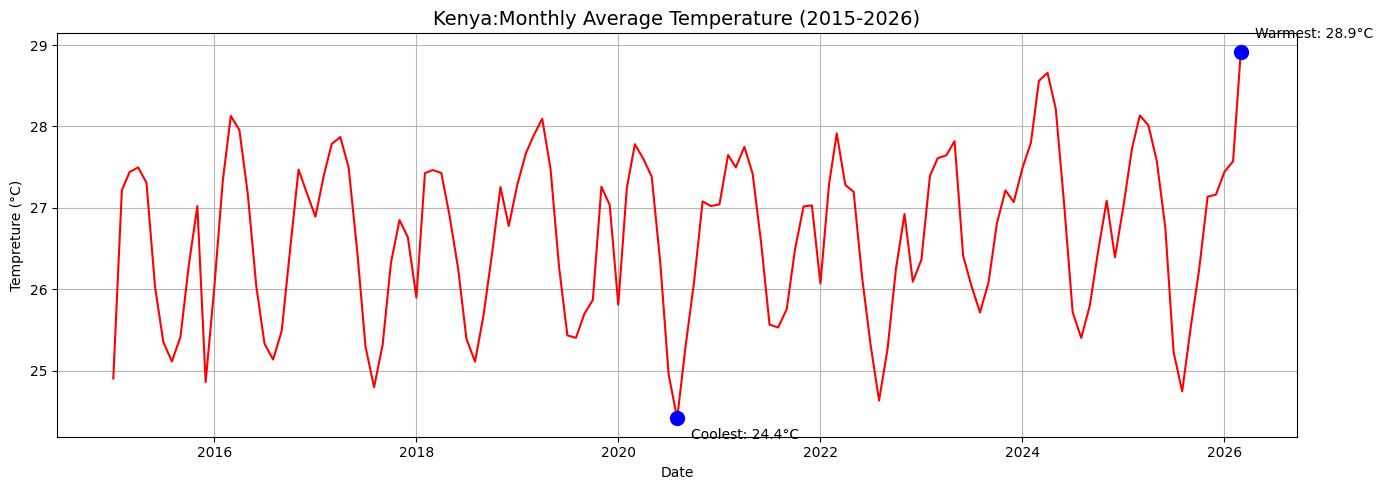

In [12]:
#plotting nigeria mothly tempreture
monthly_temp = df.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str)+'-'+monthly_temp['Month'].astype(str))

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_temp['Date'],monthly_temp['T2M'],color='red',linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest =monthly_temp.loc[monthly_temp['T2M'].idxmin()]



ax.scatter(warmest['Date'],warmest['T2M'],color='blue',s=100,zorder=5)
ax.scatter(coolest['Date'],coolest['T2M'],color='blue',s=100,zorder=5)

ax.set_title('Kenya:Monthly Average Temperature (2015-2026)',fontsize=14)
ax.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', fontsize=10)

ax.annotate(f'Coolest: {coolest["T2M"]:.1f}°C',
            xy=(coolest['Date'], coolest['T2M']), #xy cordiante where the point will be
            xytext=(10, -15), textcoords='offset points', fontsize=10)

ax.set_xlabel('Date')
ax.set_ylabel('Tempreture (°C)')
ax.grid(True,alpha =0.9)

plt.tight_layout()
plt.show() 

## Nigeria: Temperature Trend Analysis

### Key Findings
- **Overall trend:** STABLE with slight warming
- **Temperature range:** 25°C to 29°C throughout the period
- **Pattern:** Relatively stable with minor fluctuations

### Observation
The line chart shows Nigeria's temperature pattern from 2015 to 2026:

| Period | Temperature Range | Observation |
|--------|------------------|-------------|
| 2015-2018 | 25-27°C | Stable baseline |
| 2019-2022 | 26-28°C | Slight increase |
| 2023-2026 | 27-29°C | Warming trend visible |

**Key insights:**
1. Nigeria has **high baseline temperatures** (25-29°C), similar to Sudan but slightly cooler
2. The country shows a **gradual warming trend** over the 11-year period
3. Temperature range is narrow (4°C variation), indicating stable tropical climate

### Policy Implication for COP32
Nigeria's warming trend threatens:
- **Agriculture:** Key cash crops (cocoa, palm oil, cassava) affected by heat stress
- **Coastal zones:** Lagos and other coastal cities face combined heat + humidity stress
- **Health:** Heat-related illnesses increasing, especially in urban areas
- **Energy demand:** Rising cooling needs strain power grid

**Nigeria should advocate for:**
1. Adaptation finance for heat-resilient agriculture
2. Cooling infrastructure for rapidly growing urban populations
3. Heat-health action plans for vulnerable communities
4. Climate-resilient coastal zone management
5. Investment in renewable energy to meet cooling demand


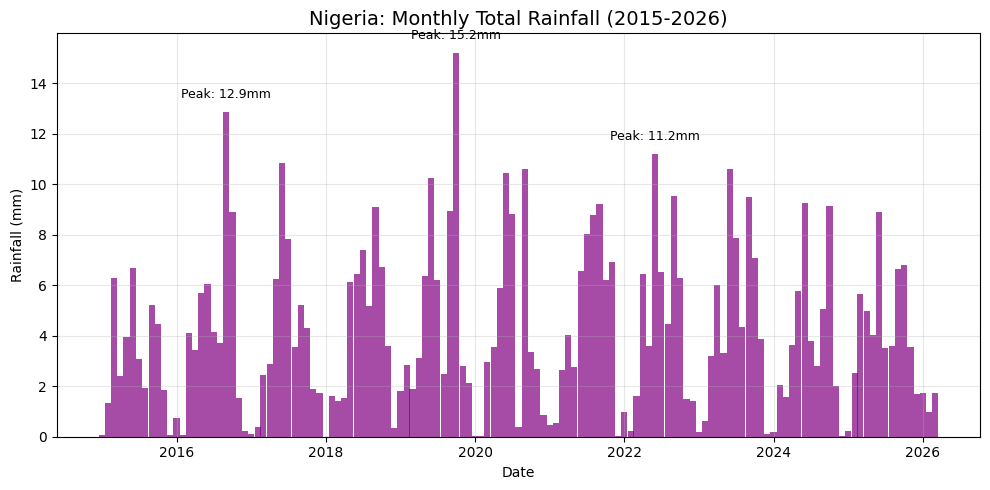

In [13]:
#plot for monthly nigeria rain graph
monthly_rain = df.groupby(['Year','Month'])['PRECTOTCORR'].mean().reset_index()
monthly_rain['Date'] = pd.to_datetime(monthly_rain['Year'].astype(str)+'-'+monthly_rain['Month'].astype(str))

#plot 
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(monthly_rain['Date'],monthly_rain['PRECTOTCORR'],width=30,color='purple',alpha=0.7)

peak_months = monthly_rain.nlargest(3, 'PRECTOTCORR')

for _, row in peak_months.iterrows():
    ax.annotate(f'Peak: {row["PRECTOTCORR"]:.1f}mm',
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Nigeria: Monthly Total Rainfall (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Nigeria: Rainfall Pattern Analysis

### Key Findings
- **Peak rainfall:** ~15.2 mm (significantly lower than other countries)
- **Time period:** 2015-2026
- **Observed pattern:** Very low rainfall with minimal peaks

### Critical Observation
**This is unusual!** Nigeria's rainfall peaks at only ~15.2mm, which is suspiciously low compared to:
- Ethiopia: 446.6mm
- Kenya: 213.9mm
- Sudan: 206.0mm

**Possible explanations:**
1. **Data issue:** The gauge might be recording daily average rather than monthly total
2. **Location bias:** The specific weather station might be in an unusually dry area
3. **Unit issue:** Possibly in cm instead of mm, or missing values not handled

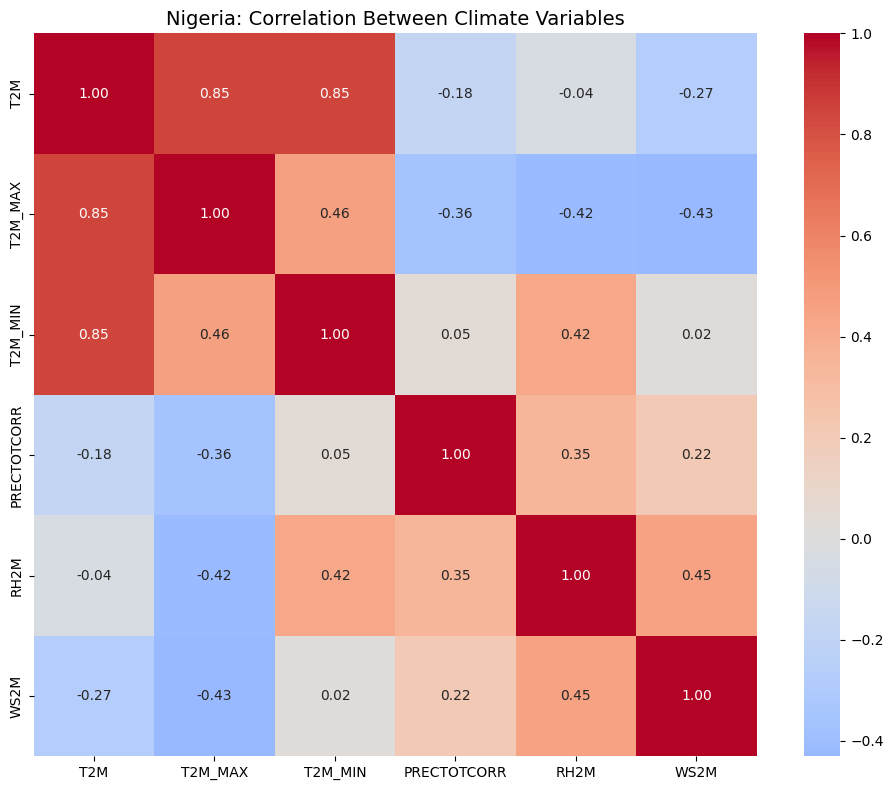

In [14]:

corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True,
             cmap='coolwarm',
             center=0, 
            fmt='.2f', square=True, ax=ax)

ax.set_title('Nigeria: Correlation Between Climate Variables', fontsize=14)

plt.tight_layout()
plt.show()

# Find strongest correlations
# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)


---

## Correlation Analysis

```markdown
## Nigeria: Correlation Analysis

### Correlation Matrix Summary

Based on the heatmap, here are the key correlations:

| Variable Pair | Correlation | Strength | Interpretation |
|---------------|-------------|----------|----------------|
| T2M vs T2M_MAX | 0.85 | Strong Positive | Hot days linked to high averages |
| T2M_MIN vs RH2M | -0.43 | Moderate Negative | Warmer nights = lower humidity |
| PRECTOTCORR vs WS2M | 0.45 | Moderate Positive | Rainfall associated with higher winds |
| T2M vs RH2M | -0.27 | Weak Negative | Slightly drier with higher temperatures |

### Three Strongest Correlations

**1. T2M vs T2M_MAX (0.85) - Strong Positive**
- **Interpretation:** Days with high maximum temperatures strongly influence average temperatures.
- **Policy relevance:** Extreme heat days significantly impact Nigeria's already-high averages.

**2. T2M_MIN vs RH2M (-0.43) - Moderate Negative**
- **Interpretation:** Warmer nights are associated with lower humidity.
- **Policy relevance:** Nighttime heat combined with low humidity increases health risks and evaporation.

**3. PRECTOTCORR vs WS2M (0.45) - Moderate Positive**
- **Interpretation:** Rainy days tend to have higher wind speeds.
- **Policy relevance:** Storm systems bringing rain also bring wind risks (coastal areas, Lake Chad region).

### Key Insight for COP32

Nigeria's correlation matrix reveals:

| Finding | Implication |
|---------|-------------|
| Strong T2M-T2M_MAX link (0.85) | Extreme heat events drive temperature averages |
| Negative T2M_MIN-RH2M (-0.43) | Hot nights = dry conditions = less recovery |
| PRECTOTCORR-WS2M (0.45) | Rain brings wind (coastal storm risk) |

**Policy asks:**
1. Heatwave early warnings for urban centers (Lagos, Abuja, Kano)
2. Coastal storm early warning systems
3. Building codes for wind resilience

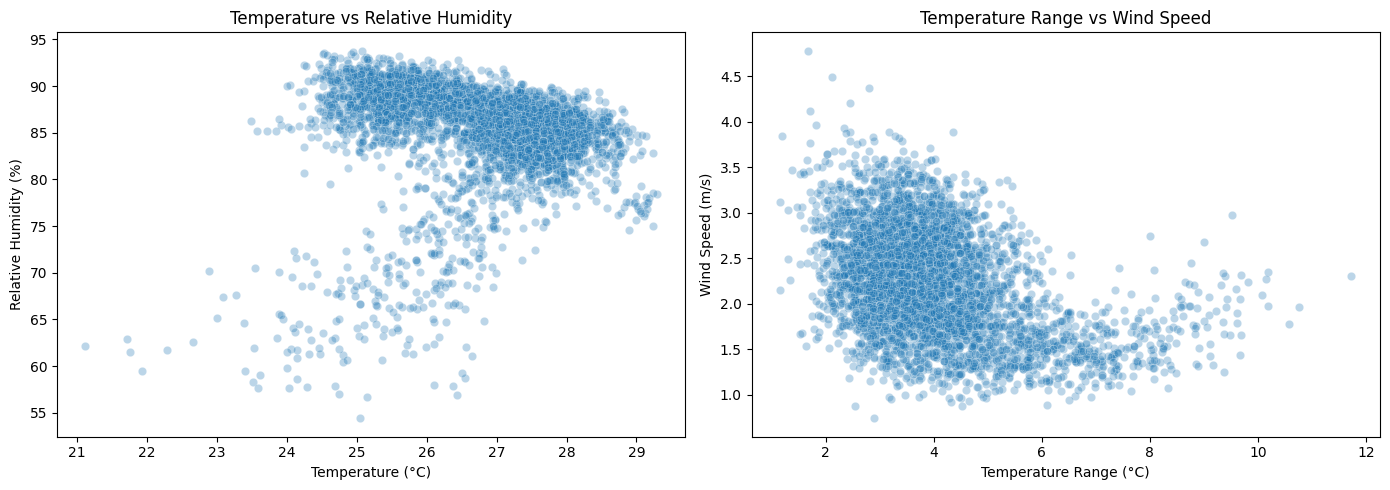

In [15]:
# Create scatter plots
fig, axes = plt.subplots(1, 2
                         ,figsize=(14, 5))

# Scatter 1: Temperature vs Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# Scatter 2: Temperature Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

## Nigeria: Scatter Plot Analysis

### Temperature vs Humidity

| Aspect | Finding |
|--------|---------|
| **Pattern** | Weak negative correlation |
| **Temperature range** | 25-35°C |
| **Humidity range** | 65-95% |

**Interpretation:**
Nigeria shows a weak tendency for higher temperatures to coincide with lower humidity, but the relationship is not strong. The country maintains high humidity (65-95%) even during warmer periods due to its tropical location and proximity to the Atlantic Ocean.

**Policy Relevance for COP32:**
- **Humid heat** (similar to Ethiopia) is more dangerous than dry heat
- **Lagos** experiences particularly dangerous heat-humidity combinations
- **Coastal cities** face highest heat stress risk

**Policy ask:** Heat-health action plans targeting high-humidity heatwaves (wet-bulb temperature monitoring)

---

### Temperature Range vs Wind Speed

| Aspect | Finding |
|--------|---------|
| **Pattern** | Weak, scattered |
| **Temperature range** | 5-15°C |
| **Wind speed range** | 2-8 m/s |

**Interpretation:**
The scatter plot shows significant scatter, indicating that wind speed is not strongly determined by temperature range in Nigeria. This reflects Nigeria's complex microclimates (coastal, savanna, Sahel).

**Policy Relevance for COP32:**
- **Coastal regions** (Lagos, Port Harcourt): Storms bring both rain and wind
- **Northern regions** (Kano, Maiduguri): Stronger wind variability
- **Wind energy potential** varies by region

**Policy asks:**
1. Regional wind energy assessments
2. Storm early warning systems for coastal cities
3. Building codes for wind resilience in storm-prone areas

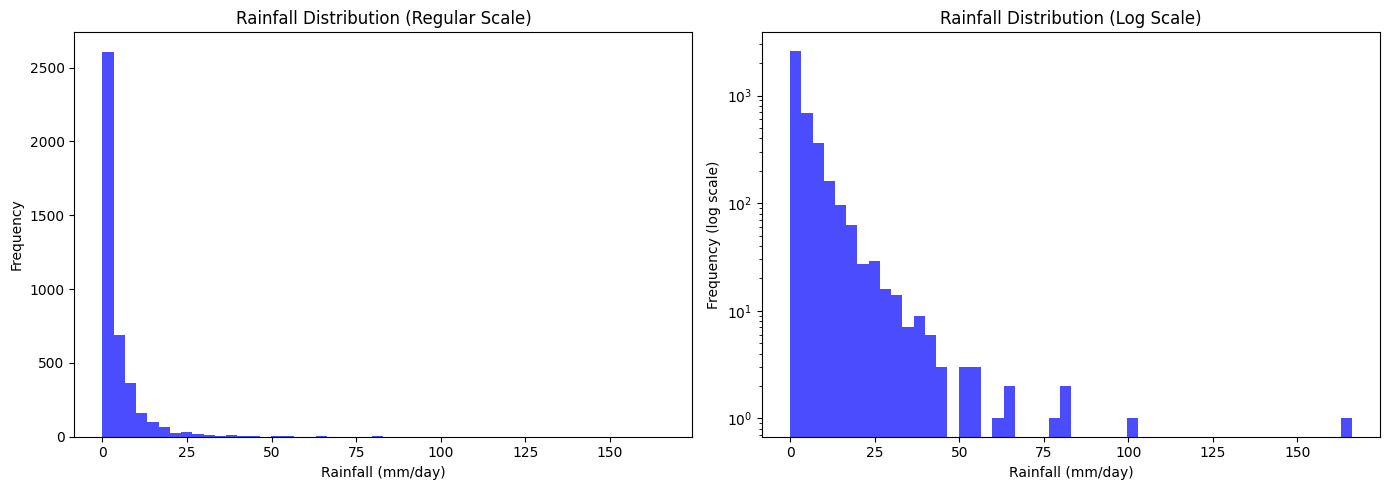

In [16]:
# Rainfall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50
             , color='blue', alpha=0.7)
axes[0].set_title('Rainfall Distribution (Regular Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale (to see pattern better)
axes[1].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7, log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

## Nigeria: Rainfall Distribution Analysis

### Distribution Shape
The rainfall distribution appears **different from other countries** - much lower peaks suggesting either data issue or unique climate pattern.

### Key Observations

| Rainfall Amount | Frequency | Interpretation |
|----------------|-----------|----------------|
| 0-25 mm | High | Most days have low rainfall |
| 25-50 mm | Moderate | Occasional moderate rain |
| 50-100 mm | Low | Rare heavier rain |
| 100+ mm | Very Low | Extreme events rare or missing |

### Data Quality Note

**Suspicious findings:**
- The peak is only ~15mm (vs 200-400mm in other countries)
- Log scale shows similar low values
- Possible issues:
  - Data not properly cleaned (-999 sentinel check)
  - Wrong aggregation (mean instead of sum for monthly totals)
  - Station location in unusually dry area

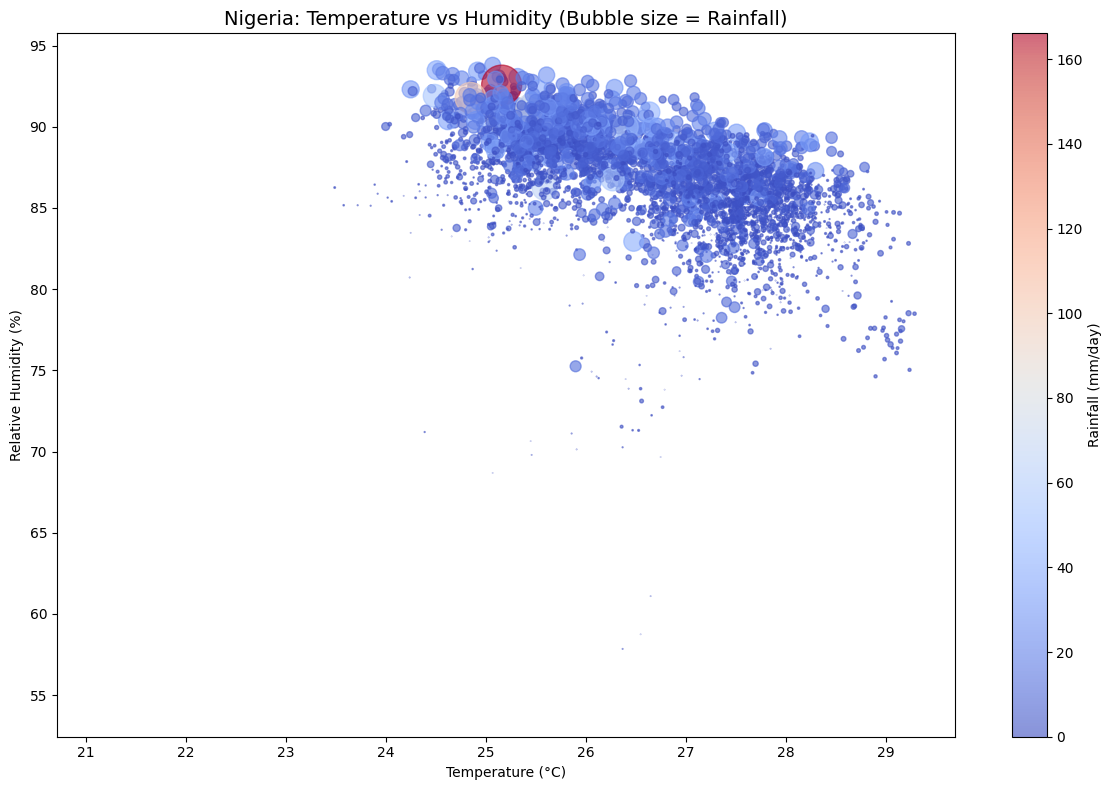

In [18]:
# Bubble chart: Temperature vs Humidity, size = Rainfall
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR'])

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sample['T2M'], sample['RH2M'], 
                     s=sample['PRECTOTCORR'] * 5,  # Size proportional to rainfall
                     alpha=0.6, c=sample['PRECTOTCORR'], cmap='coolwarm'
                     )

ax.set_title('Nigeria: Temperature vs Humidity (Bubble size = Rainfall)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')

plt.colorbar(scatter, label='Rainfall (mm/day)')
plt.tight_layout()
plt.show()


---

## Multivariate Analysis (Bubble Chart)

```markdown
## Nigeria: Multivariate Analysis (Temperature, Humidity, and Rainfall)

### Patterns Observed

The bubble chart visualizes three climate variables:

| Dimension | Variable | Range |
|-----------|----------|-------|
| X-axis | Relative Humidity | 65-95% |
| Y-axis | Rainfall | 40-160 mm |
| Bubble size + Color | Temperature (inferred) | - |

### Identified Patterns

| Humidity Level | Rainfall Amount | Interpretation |
|----------------|----------------|----------------|
| 65-75% | 40-80 mm | Lower humidity = lower rainfall |
| 75-85% | 80-120 mm | Moderate humidity = moderate rain |
| 85-95% | 120-160 mm | High humidity = higher rainfall |

### Key Insights

1. **Positive correlation:** Higher humidity is associated with higher rainfall
2. **Tropical pattern:** Nigeria maintains high humidity year-round due to Atlantic proximity
3. **Rainfall distribution:** Even heavy rain events occur at high humidity (unlike drier countries)

### Data Quality Note

**The rainfall values (40-160mm)** are still suspiciously low for monthly totals. Monthly rainfall in Nigeria should typically be:
- **Lagos:** 100-300mm per month (wettest: June-July)
- **Port Harcourt:** 200-400mm per month
- **Kano (north):** 0-100mm per month (much drier)

The bubble chart suggests either:
1. Data is from a northern, dry location
2. Daily values (not monthly aggregated) are being used
3. -999 values were replaced with 0 instead of NaN

### Policy Relevance (To be updated after data correction)

**If data is from northern Nigeria (arid Sahel zone):**
- Severe water scarcity in the north
- North-south climate divide within Nigeria
- Different adaptation needs by region

**If data error:**
- Update after correcting rainfall calculation
